In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, "..")

import cv2
import numpy as np
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120
matplotlib.rcParams["figure.autolayout"] = True
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from src.config import PREPROCESSING_CONFIG, PATHS
from src.preprocess import ImagePreprocessor
from src.geometry import bgr2rgb
from src.dataset import load_manifest
from pathlib import Path

OUTPUT_DIR = PATHS["output_dir"] / "07_preprocessing_sandbox"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

manifest = load_manifest()
sample = manifest.sample(1, random_state=7).iloc[0]
img_bgr = cv2.imread(str(sample["path"]))
print(f"Osztály: {sample['class']}  |  {sample['path'].name}")
print(f"Kép méret: {img_bgr.shape}")
print(f"Mentési mappa: {OUTPUT_DIR}")
print(f"\nAktív PREPROCESSING_CONFIG:")
for k, v in PREPROCESSING_CONFIG.items():
    print(f"  {k}: {v}")

Osztály: F  |  1762212513789.jpg
Kép méret: (3488, 4640, 3)
Mentési mappa: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/output/07_preprocessing_sandbox

Aktív PREPROCESSING_CONFIG:
  clahe_enabled: True
  clahe_clip_limit: 2.0
  clahe_tile_grid_size: (8, 8)
  blur_enabled: False
  blur_ksize: 3
  normalize_enabled: False
  normalize_method: minmax


## 1. Preprocessing stádiumok összehasonlítása

Bal → jobb: Eredeti → CLAHE → Canny(eredeti) → Canny(CLAHE után)

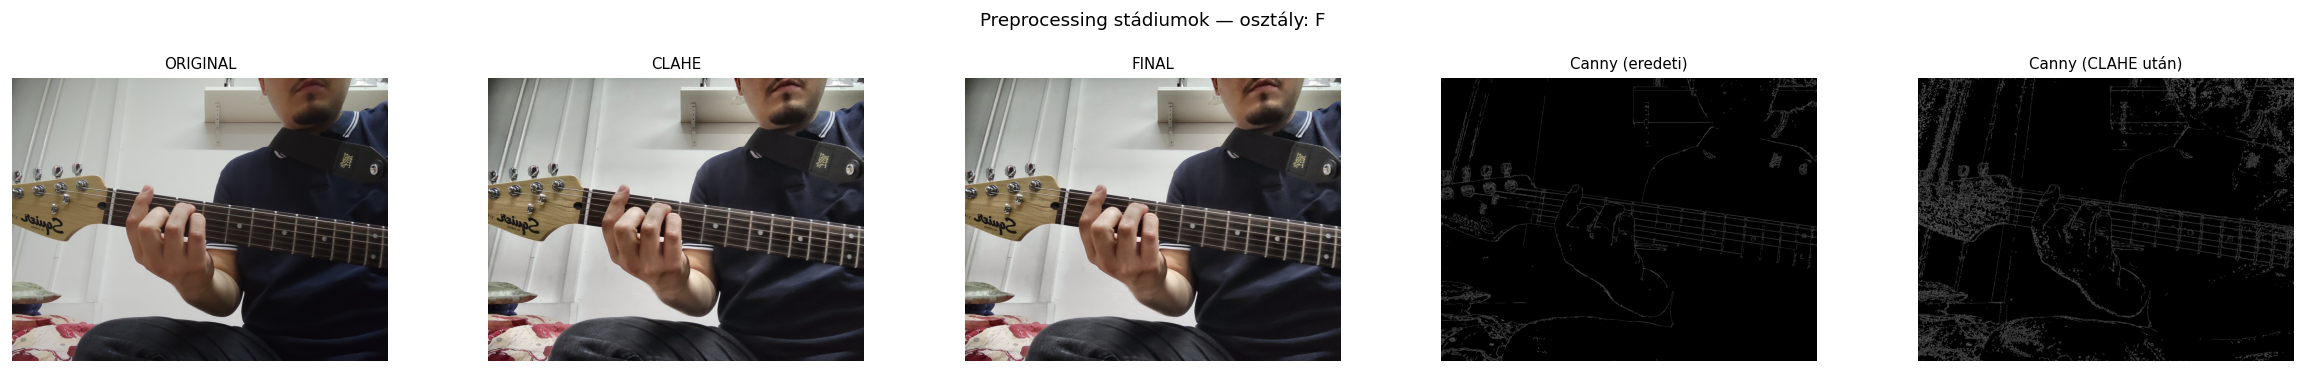

Ábra elmentve: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/output/07_preprocessing_sandbox/01_preprocessing_stages.png


In [3]:
from src.geometry import step1_canny

prep = ImagePreprocessor()
stages = prep.process_stages(img_bgr)

# Stádiumok sorrendben
stage_keys = ["original", "clahe"]
if "blur"       in stages: stage_keys.append("blur")
if "normalized" in stages: stage_keys.append("normalized")
stage_keys.append("final")

canny_orig = step1_canny(stages["original"])
canny_pre  = step1_canny(stages["final"])

n = len(stage_keys) + 2
fig, axes = plt.subplots(1, n, figsize=(4 * n, 3))

for ax, key in zip(axes[:len(stage_keys)], stage_keys):
    ax.imshow(bgr2rgb(stages[key]))
    ax.set_title(key.upper(), fontsize=9)
    ax.axis("off")

axes[-2].imshow(canny_orig, cmap="gray")
axes[-2].set_title("Canny (eredeti)", fontsize=9)
axes[-2].axis("off")

axes[-1].imshow(canny_pre, cmap="gray")
axes[-1].set_title("Canny (CLAHE után)", fontsize=9)
axes[-1].axis("off")

fig_path = OUTPUT_DIR / "01_preprocessing_stages.png"
plt.suptitle(f"Preprocessing stádiumok — osztály: {sample['class']}", fontsize=11, y=1.02)
plt.tight_layout()
fig.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Ábra elmentve: {fig_path}")

## 2. Intenzitás-profil: CLAHE előtt vs. után (kanonikus térben)

A kanonikus kép (600×80 px) oszloponkénti intenzitás-átlaga mutatja, 
hogyan különülnek el a bundok és a nut a háttértől CLAHE alkalmazása után.

I0000 00:00:1779225752.283906 1191243 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1779225752.286394 1191257 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-2), renderer: Mesa Intel(R) Iris(R) Xe Graphics (TGL GT2)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1779225752.298971 1191248 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779225752.317142 1191247 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779225752.576350 1191246 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


  [outer_edges_v9] vonalak: 10 | bal outlier: nem | jobb outlier: igen
  [outer_edges_v9] Bal oldal bővítve: -37.8px
  [outer_edges_v9] szétválasztás: 344.7px (klaszter: 126.0px | bővítés: 37.8px)
  [trapezoid_v9] span=3797.9px | w_start=344.7px | w_end=344.7px | area=1439848px²
  [nut_side] tip_mean=224 vs wrist=280 → left
  [nut_detect_v12] side_hint=left | median=1318 | peak=9787 | ratio=7.43 | fwhm=7.0px
  [nut_detect_v12] nut találat: left @ x=34px (fwhm=7.0px)
  [shear_corr] n=34 | α=-2.68° | s=-0.0468 → korrigált
  [nut_detect_v12] side_hint=left | median=1316 | peak=10283 | ratio=7.82 | fwhm=5.0px
  [nut_detect_v12] nut találat: left @ x=236px (fwhm=5.0px)
  [fret_fit v11] nut-anchored | scale=805.8px | cov=54% (13/24)
  [fret_fit v11] nut-anchored | scale=805.8px | cov=54% (13/24)
  [outer_edges_v9] vonalak: 13 | bal outlier: nem | jobb outlier: nem
  [outer_edges_v9] Bal oldal bővítve: -113.1px
  [outer_edges_v9] Jobb oldal bővítve: +113.1px
  [outer_edges_v9] szétválasztás: 

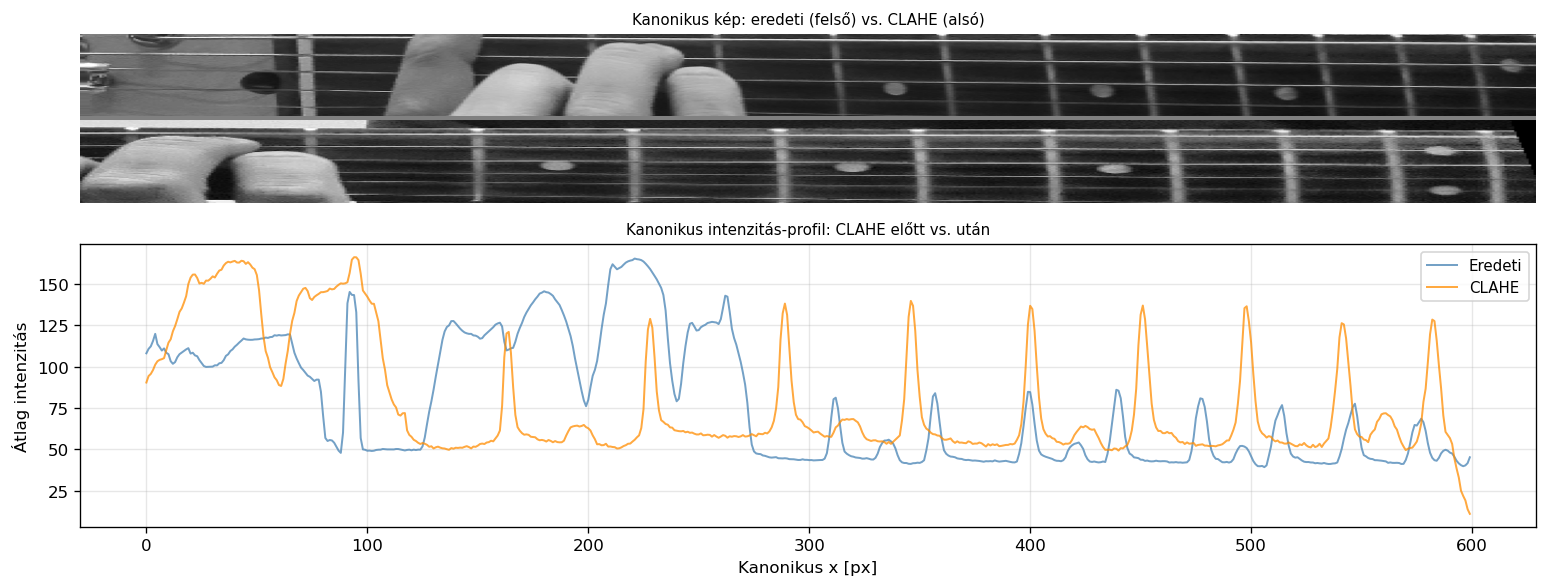

Ábra elmentve: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/output/07_preprocessing_sandbox/02_canonical_intensity_profile.png
Pipeline OK — eredeti: True  |  CLAHE: True
Coverage ratio — eredeti: 0.542  |  CLAHE: 0.333


In [4]:
from src.fretboard import run_v14_pipeline

entry = {"path": sample["path"], "class": sample["class"]}

result_orig = run_v14_pipeline(entry)
result_pre  = run_v14_pipeline(entry, preprocessor=ImagePreprocessor())

if result_orig.get("canon") is not None and result_pre.get("canon") is not None:
    canon_orig_gray = cv2.cvtColor(result_orig["canon"], cv2.COLOR_BGR2GRAY)
    canon_pre_gray  = cv2.cvtColor(result_pre["canon"],  cv2.COLOR_BGR2GRAY)

    profile_orig = canon_orig_gray.mean(axis=0).astype(np.float32)
    profile_pre  = canon_pre_gray.mean(axis=0).astype(np.float32)

    fig, axes = plt.subplots(2, 1, figsize=(13, 5), gridspec_kw={"height_ratios": [1.2, 2]})

    # Kanonikus képek egymás alatt
    combined = np.vstack([
        cv2.cvtColor(result_orig["canon"], cv2.COLOR_BGR2GRAY),
        np.full((4, result_orig["canon"].shape[1]), 128, dtype=np.uint8),
        cv2.cvtColor(result_pre["canon"],  cv2.COLOR_BGR2GRAY),
    ])
    axes[0].imshow(combined, cmap="gray", aspect="auto")
    axes[0].set_title("Kanonikus kép: eredeti (felső) vs. CLAHE (alsó)", fontsize=9)
    axes[0].axis("off")

    # Intenzitás-profil
    xs = np.arange(len(profile_orig))
    axes[1].plot(xs, profile_orig, label="Eredeti", alpha=0.75, color="steelblue",   linewidth=1.2)
    axes[1].plot(xs, profile_pre,  label="CLAHE",   alpha=0.75, color="darkorange",  linewidth=1.2)
    axes[1].set_xlabel("Kanonikus x [px]")
    axes[1].set_ylabel("Átlag intenzitás")
    axes[1].set_title("Kanonikus intenzitás-profil: CLAHE előtt vs. után", fontsize=9)
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3)

    fig_path = OUTPUT_DIR / "02_canonical_intensity_profile.png"
    plt.tight_layout()
    fig.savefig(fig_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Ábra elmentve: {fig_path}")

    ok_orig = result_orig.get("ok", False)
    ok_pre  = result_pre.get("ok",  False)
    print(f"Pipeline OK — eredeti: {ok_orig}  |  CLAHE: {ok_pre}")
    if result_orig.get("fit") and result_pre.get("fit"):
        cr_orig = result_orig["fit"].get("coverage_ratio", 0)
        cr_pre  = result_pre["fit"].get("coverage_ratio",  0)
        print(f"Coverage ratio — eredeti: {cr_orig:.3f}  |  CLAHE: {cr_pre:.3f}")
else:
    print(f"Pipeline nem adott kanonikus képet.")
    print(f"  eredeti invalid_reason: {result_orig.get('invalid_reason')}")
    print(f"  CLAHE   invalid_reason: {result_pre.get('invalid_reason')}")

## 3. CLAHE paraméter-érzékenység

Különböző `clipLimit` és `tileGridSize` beállítások vizuális összehasonlítása.

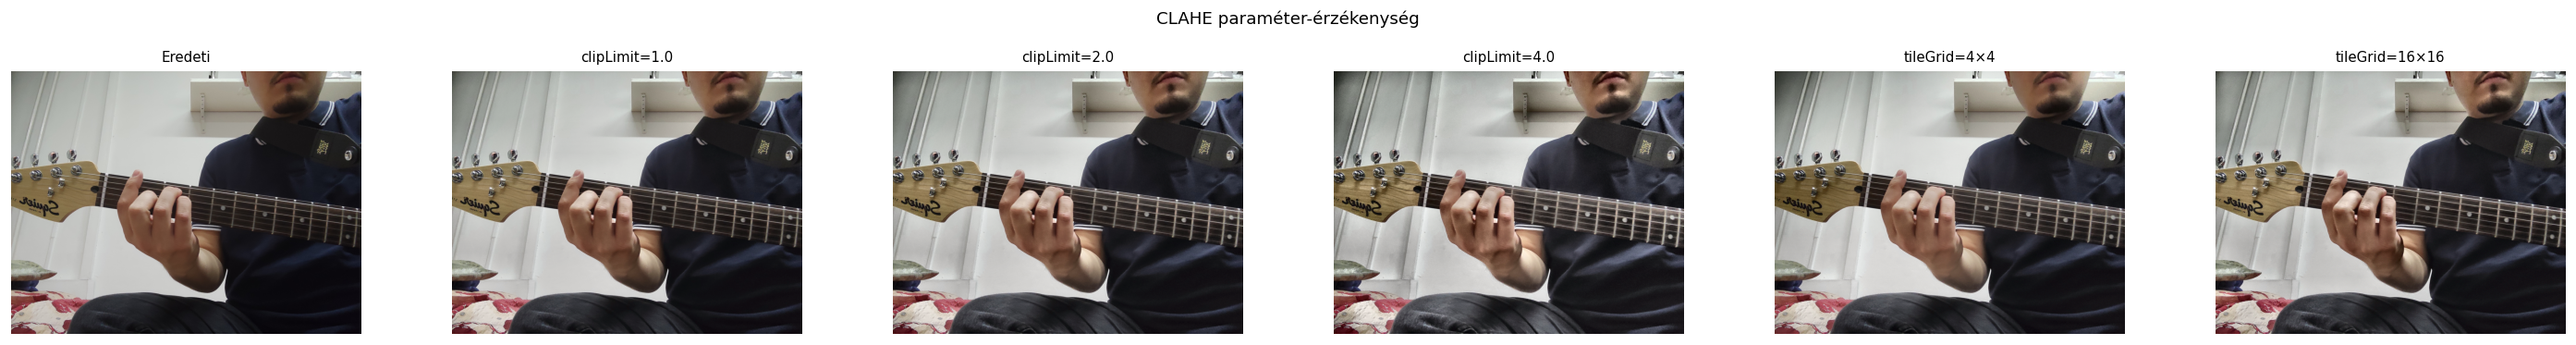

Ábra elmentve: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/output/07_preprocessing_sandbox/03_clahe_parameter_sensitivity.png


In [5]:
param_configs = [
    {"label": "clipLimit=1.0",  "clahe_enabled": True, "clahe_clip_limit": 1.0, "clahe_tile_grid_size": (8, 8), "blur_enabled": False, "normalize_enabled": False},
    {"label": "clipLimit=2.0",  "clahe_enabled": True, "clahe_clip_limit": 2.0, "clahe_tile_grid_size": (8, 8), "blur_enabled": False, "normalize_enabled": False},
    {"label": "clipLimit=4.0",  "clahe_enabled": True, "clahe_clip_limit": 4.0, "clahe_tile_grid_size": (8, 8), "blur_enabled": False, "normalize_enabled": False},
    {"label": "tileGrid=4×4",   "clahe_enabled": True, "clahe_clip_limit": 2.0, "clahe_tile_grid_size": (4, 4), "blur_enabled": False, "normalize_enabled": False},
    {"label": "tileGrid=16×16", "clahe_enabled": True, "clahe_clip_limit": 2.0, "clahe_tile_grid_size": (16, 16), "blur_enabled": False, "normalize_enabled": False},
]

n = len(param_configs) + 1
fig, axes = plt.subplots(1, n, figsize=(4 * n, 3))

axes[0].imshow(bgr2rgb(img_bgr))
axes[0].set_title("Eredeti", fontsize=9)
axes[0].axis("off")

for ax, pcfg in zip(axes[1:], param_configs):
    cfg = {k: v for k, v in pcfg.items() if k != "label"}
    out_img = ImagePreprocessor(config=cfg).process(img_bgr)
    ax.imshow(bgr2rgb(out_img))
    ax.set_title(pcfg["label"], fontsize=9)
    ax.axis("off")

fig_path = OUTPUT_DIR / "03_clahe_parameter_sensitivity.png"
plt.suptitle("CLAHE paraméter-érzékenység", fontsize=11, y=1.02)
plt.tight_layout()
fig.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Ábra elmentve: {fig_path}")

## 4. Blur + CLAHE kombináció

A pipeline-szintű blur (Gaussian, ksize=3) és CLAHE együttes hatása.

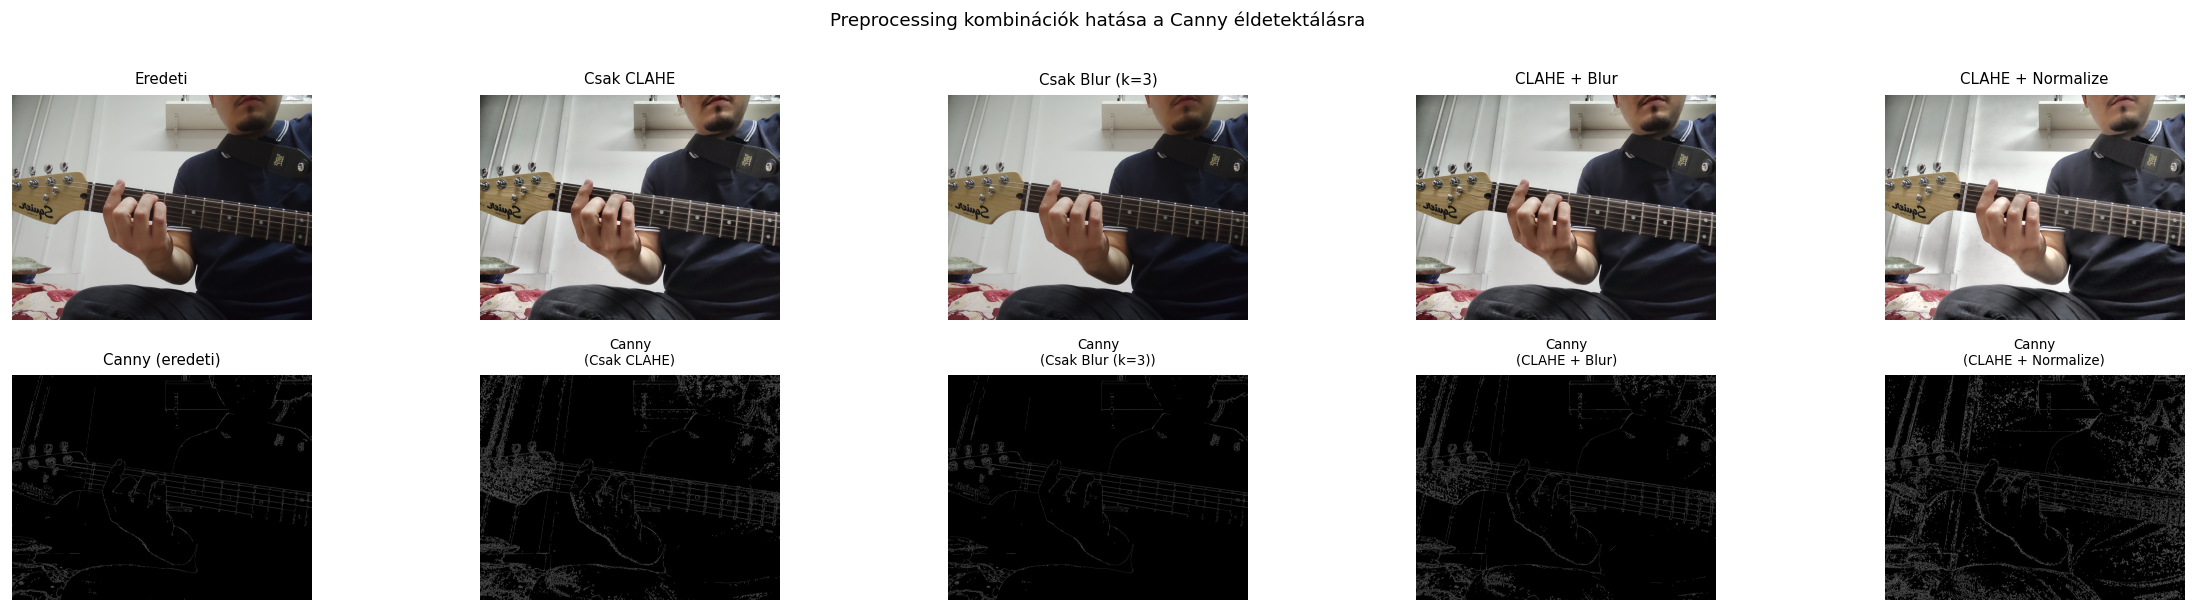

Ábra elmentve: /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/output/07_preprocessing_sandbox/04_preprocessing_combinations.png


In [6]:
combo_configs = [
    {"label": "Csak CLAHE",       "clahe_enabled": True,  "clahe_clip_limit": 2.0, "clahe_tile_grid_size": (8, 8), "blur_enabled": False, "normalize_enabled": False},
    {"label": "Csak Blur (k=3)",  "clahe_enabled": False, "clahe_clip_limit": 2.0, "clahe_tile_grid_size": (8, 8), "blur_enabled": True,  "blur_ksize": 3, "normalize_enabled": False},
    {"label": "CLAHE + Blur",     "clahe_enabled": True,  "clahe_clip_limit": 2.0, "clahe_tile_grid_size": (8, 8), "blur_enabled": True,  "blur_ksize": 3, "normalize_enabled": False},
    {"label": "CLAHE + Normalize","clahe_enabled": True,  "clahe_clip_limit": 2.0, "clahe_tile_grid_size": (8, 8), "blur_enabled": False, "normalize_enabled": True, "normalize_method": "histogram_eq"},
]

n = len(combo_configs) + 1
fig, axes = plt.subplots(2, n, figsize=(4 * n, 5))

axes[0, 0].imshow(bgr2rgb(img_bgr))
axes[0, 0].set_title("Eredeti", fontsize=9)
axes[0, 0].axis("off")
axes[1, 0].imshow(step1_canny(img_bgr), cmap="gray")
axes[1, 0].set_title("Canny (eredeti)", fontsize=9)
axes[1, 0].axis("off")

for col, ccfg in enumerate(combo_configs, start=1):
    cfg = {k: v for k, v in ccfg.items() if k != "label"}
    out_img = ImagePreprocessor(config=cfg).process(img_bgr)
    axes[0, col].imshow(bgr2rgb(out_img))
    axes[0, col].set_title(ccfg["label"], fontsize=9)
    axes[0, col].axis("off")
    axes[1, col].imshow(step1_canny(out_img), cmap="gray")
    axes[1, col].set_title(f"Canny\n({ccfg['label']})", fontsize=8)
    axes[1, col].axis("off")

fig_path = OUTPUT_DIR / "04_preprocessing_combinations.png"
plt.suptitle("Preprocessing kombinációk hatása a Canny éldetektálásra", fontsize=11, y=1.01)
plt.tight_layout()
fig.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Ábra elmentve: {fig_path}")